<!-- FULL: keep, DEMO: keep -->
<div style='display:flex; align-items:center; justify-content:space-between; border-bottom: 3px solid rgb(255,106,0); padding-bottom:1em; margin-bottom:1em'>
<div>
<span style='color:rgb(22,60,105); font-size:1.8em; font-weight:bold;'>Introduction to Deep Learning</span><br>
<span style='color:rgb(0,85,100); font-size:1.3em;'>Session 10 &mdash; Pretraining</span><br>
<span style='color:rgb(0,85,100); font-size:1.0em;'>Magda Gregorová &nbsp;·&nbsp; THWS &nbsp;·&nbsp; June 2026</span>
</div>
<img src='../../Common/Pics/thws-logo_vert_en_orange-rgb.png' style='height:80px;'/>
</div>

In [19]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
from models import SimpleCNN

In [2]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

<!-- FULL: keep, DEMO: keep -->
<div style='border-left: 4px solid rgb(255,106,0); padding: 0.3em 0.8em; background: rgb(255,250,245); margin: 1.5em 0 0.5em 0;'>
<strong style='color:rgb(22,60,105); font-size:1.05em;'>Tiny CIFAR-10 data</strong>
</div>

CIFAR-10 32x32 images in RGB subsampled for the demo to 500 images

In [10]:
# Download Full CIFAR-10 - 32x32 images
full_train_dataset = torchvision.datasets.CIFAR10(root='../../data', train=True, download=True, transform=transforms.ToTensor())
test_dataset = torchvision.datasets.CIFAR10(root='../../data', train=False, download=True, transform=transforms.ToTensor())

print(f"Full training set size: {len(full_train_dataset)}")
print(f"Full testing set size: {len(test_dataset)}")

/home/magda/venvs/idl/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Full training set size: 50000
Full testing set size: 10000


In [13]:
# FOR THIS LESSON: Subsample to a tiny dataset (e.g., 500 images total)
tiny_train_indices = torch.randperm(len(full_train_dataset))[:500]
# print(tiny_train_indices)
tiny_train_dataset = Subset(full_train_dataset, tiny_train_indices)

print(f"Tiny training set size: {len(tiny_train_dataset)}")

Tiny training set size: 500


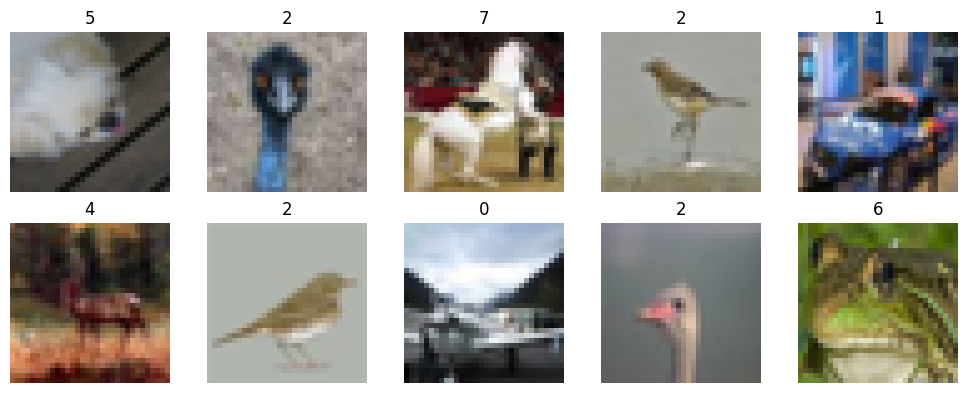

In [ ]:
# display examples
fig, axes = plt.subplots(1, 5, figsize=(10, 4))

for ax, idx in zip(axes.ravel(), range(10)):
    img, label = tiny_train_dataset[idx]
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(label)
    ax.axis("off")

plt.tight_layout()

<!-- FULL: keep, DEMO: keep -->
<div style='border-left: 4px solid rgb(255,106,0); padding: 0.3em 0.8em; background: rgb(255,250,245); margin: 1.5em 0 0.5em 0;'>
<strong style='color:rgb(22,60,105); font-size:1.05em;'>Train from scratch</strong>
</div>

Train on tiny dataset using basic CNN model

In [ ]:
# basic setups
model_scratch = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_scratch.parameters(), lr=0.001)